In [14]:
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
import sys
sys.path.append(root)
sys.path.append(src)

## Define the materials
from src.photonic_crystal_maker import Material
from src.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal, ScriptParam, ScriptParamVector3
from src.mpb_configurator import MPBSchemeConfigurator  
import meep as mp
from src.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from src.mpb_configurator import *

n_InP = 3.1
eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "final_h_sweep_opt"

## Define the geometry
radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
height_supercell = 3
height_slab = ScriptParam("h", 0.4)
slab_block_size = ScriptParamVector3(1e20, 1e20, "h", z_def = 0.4)

## Define the lattice
lattice_2D = Lattice(type="TXY")
lattice_slab = Lattice(type="TXY", size=mp.Vector3(1, 1, height_supercell))
centers = lattice_2D.get_centers()
k_points = lattice_2D.get_high_symmetry_k_points()



bulk_2D = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": InP})
bulk_slab = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": slab_block_size, "material": InP})
hole1_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": 1e20, "material": air})
hole2_2D = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": 1e20, "material": air})
hole1_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": height_slab, "material": air})
hole2_slab = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": height_slab, "material": air})

photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=[bulk_2D, hole1_2D, hole2_2D])
photonic_crystal_slab = PhotonicCrystal(lattice=lattice_slab, atoms=[bulk_slab, hole1_slab, hole2_slab])

## Define the simulation
configuration_options = dict(
    resolution = 32, 
    num_bands=8,
    k_points=[mp.Vector3(0,0,0)], 
)

mpb_configuration_2D = MPBSchemeConfigurator(photonic_crystal_2D, ["te", "tm"], **configuration_options)
mpb_configuration_slab = MPBSchemeConfigurator(photonic_crystal_slab, ["zeven", "zodd"], **configuration_options)
script_2D = mpb_configuration_2D.get_scheme_config(join_newline=True)
script_slab = mpb_configuration_slab.get_scheme_config(join_newline=True)


Epsilon of InP:  9.61
COMMANDS ['(define-param r1 0.3)', '(define-param r2 0.2)']
COMMANDS ['(define-param h 0.4)', '(define-param r1 0.3)', '(define-param r2 0.2)']


In [15]:
import concurrent.futures
import matplotlib.pyplot as plt
from src.optimization_data_analyzer import OptimizationDataAnalyzer
from src.lsf_job_configurator import LSFJobConfiguration
from src.mpi_differential_evolution import MPIdeOptimizator

# Assume 'name' and 'script_slab' are defined elsewhere
np = 32
pop = np // 2
h_array = [0.3, 0.32, 0.35, 0.37, 0.4, 0.42, 0.45, 0.5, 0.55, 0.6, 0.7, 0.8]

def run_optimization(h):
    lsf_config = LSFJobConfiguration(num_processors=np, walltime="04:00", span_value = 1)
    opt_name = f"{name}_h_{h:0.2f}"
    optimizer = MPIdeOptimizator(
        simulation_name=opt_name,
        scheme_script=script_slab,
        maxiter=20,
        param_names=["r1", "r2"],
        param_bounds=[(0.05, 0.3), (0.05, 0.3)],
        polarization="zodd",
        de_options={"strategy": "rand1bin", "popsize": pop},
        bands=[6, 7, 8],
        height_slab=h
    )
    # Submit the LSF job.
    submission_info = optimizer.submit_lsf_job(lsf_config)
    try:
        data_file = optimizer.data_file
        analyzer = OptimizationDataAnalyzer(data_file)
        plt.figure()
        analyzer.plot_raw_data(plot_inverse_cost=True, points_only=True, use_logscale=True)        
        plt.savefig(f"{opt_name}_raw_data_log_point.png")
        plt.close()
        plt.figure()
        analyzer.plot_optimization_points_freq_dirac(points_only=True)
        plt.savefig(f"{opt_name}_freq_center.png")
        plt.close()
    except Exception as e:
        print(f"An error occurred while analyzing the data: {e}")

# Use ThreadPoolExecutor to run jobs concurrently.
with concurrent.futures.ThreadPoolExecutor() as executor:
    executor.map(run_optimization, h_array)


LSF job script written to: final_h_sweep_opt_h_0.30/final_h_sweep_opt_h_0.30.sh
LSF job script written to: final_h_sweep_opt_h_0.32/final_h_sweep_opt_h_0.32.sh
LSF job script written to: final_h_sweep_opt_h_0.35/final_h_sweep_opt_h_0.35.sh
LSF job script written to: final_h_sweep_opt_h_0.37/final_h_sweep_opt_h_0.37.sh
LSF job script written to: final_h_sweep_opt_h_0.40/final_h_sweep_opt_h_0.40.sh
LSF job script written to: final_h_sweep_opt_h_0.42/final_h_sweep_opt_h_0.42.sh
LSF job script written to: final_h_sweep_opt_h_0.45/final_h_sweep_opt_h_0.45.sh
LSF job script written to: final_h_sweep_opt_h_0.50/final_h_sweep_opt_h_0.50.sh
LSF job script written to: final_h_sweep_opt_h_0.55/final_h_sweep_opt_h_0.55.sh
LSF job script written to: final_h_sweep_opt_h_0.60/final_h_sweep_opt_h_0.60.sh
LSF job script written to: final_h_sweep_opt_h_0.70/final_h_sweep_opt_h_0.70.sh
LSF job script written to: final_h_sweep_opt_h_0.80/final_h_sweep_opt_h_0.80.sh
Job submitted successfully. Submission o

/zhome/2f/7/202918/phc_nzi/src/optimization_data_analyzer.py:133: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(7, 6))


Job 24418861 status: RUN, elapsed time: 4368 sec
Job 24418861 status: RUN, elapsed time: 4378 sec
Job 24418861 status: RUN, elapsed time: 4388 sec
Job 24418861 status: RUN, elapsed time: 4398 sec
Job 24418861 status: RUN, elapsed time: 4408 sec
Job 24418861 status: RUN, elapsed time: 4418 sec
Job 24418861 status: RUN, elapsed time: 4428 sec
Job 24418861 status: RUN, elapsed time: 4438 sec
Job 24418861 status: RUN, elapsed time: 4448 sec
Job 24418861 status: RUN, elapsed time: 4458 sec
Job 24418861 status: RUN, elapsed time: 4468 sec
Job 24418861 status: RUN, elapsed time: 4478 sec
Job 24418861 status: RUN, elapsed time: 4488 sec
Job 24418861 status: RUN, elapsed time: 4498 sec
Job 24418861 status: DONE, elapsed time: 4508 sec
Job 24418861 finished.


/tmp/ipykernel_2064813/1903168036.py:31: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Plotting test_h_sweep_opt_h_0.20.de.data
Plotting test_h_sweep_opt_h_0.30.de.data
Plotting test_h_sweep_opt_h_0.35.de.data
Plotting test_h_sweep_opt_h_0.40.de.data
Plotting test_h_sweep_opt_h_0.45.de.data
Plotting test_h_sweep_opt_h_0.50.de.data
Plotting test_h_sweep_opt_h_0.55.de.data
Plotting test_h_sweep_opt_h_0.60.de.data
Plotting test_h_sweep_opt_h_0.70.de.data
Plotting test_h_sweep_opt_h_0.80.de.data


<Figure size 640x480 with 0 Axes>

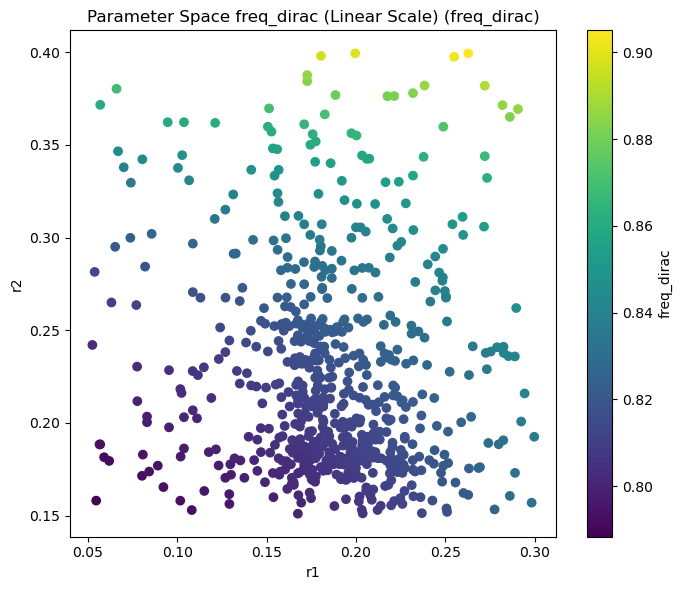

<Figure size 640x480 with 0 Axes>

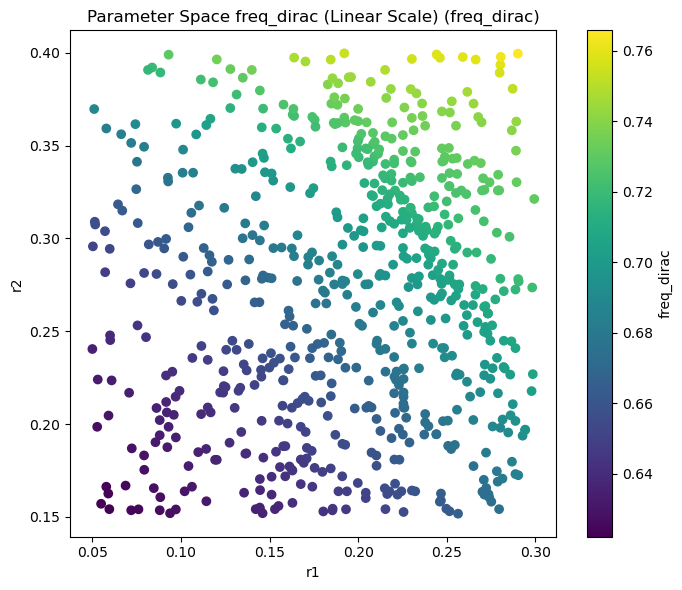

<Figure size 640x480 with 0 Axes>

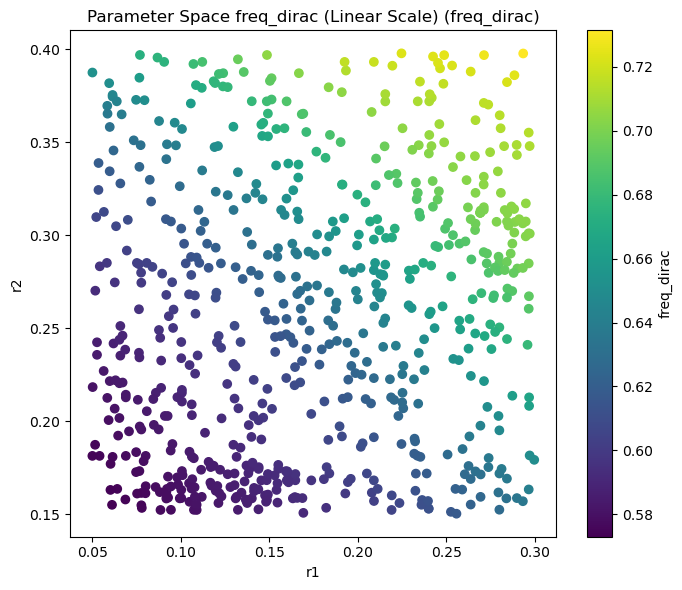

<Figure size 640x480 with 0 Axes>

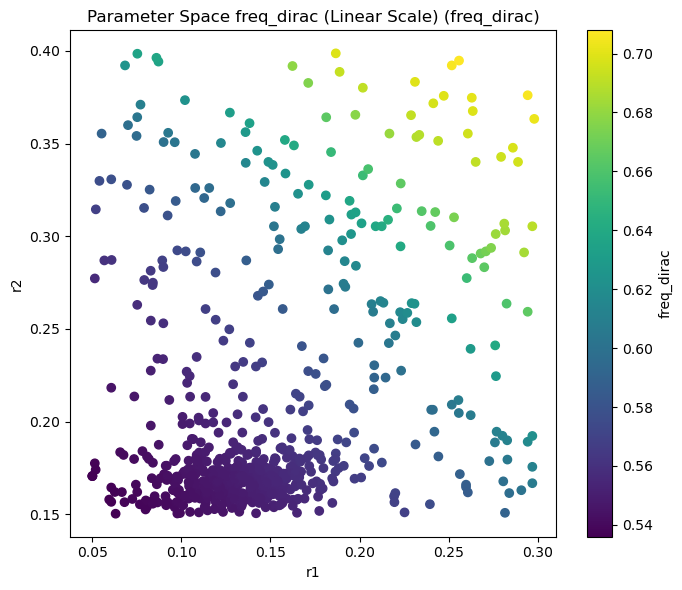

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

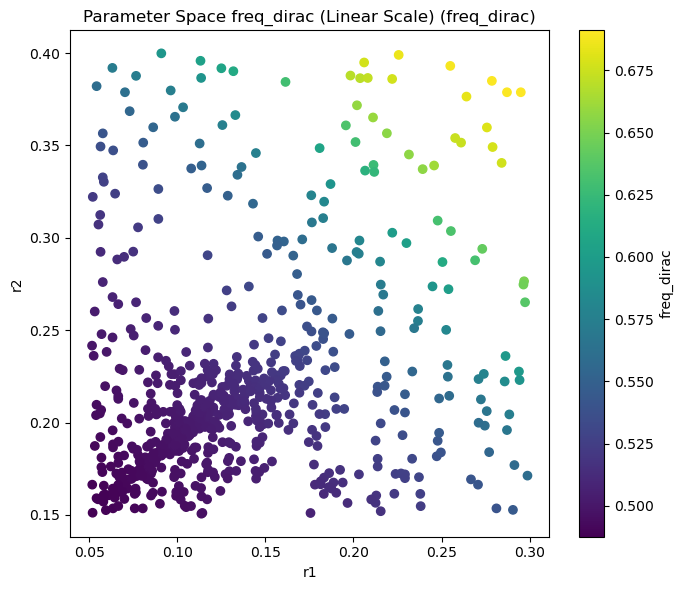

<Figure size 640x480 with 0 Axes>

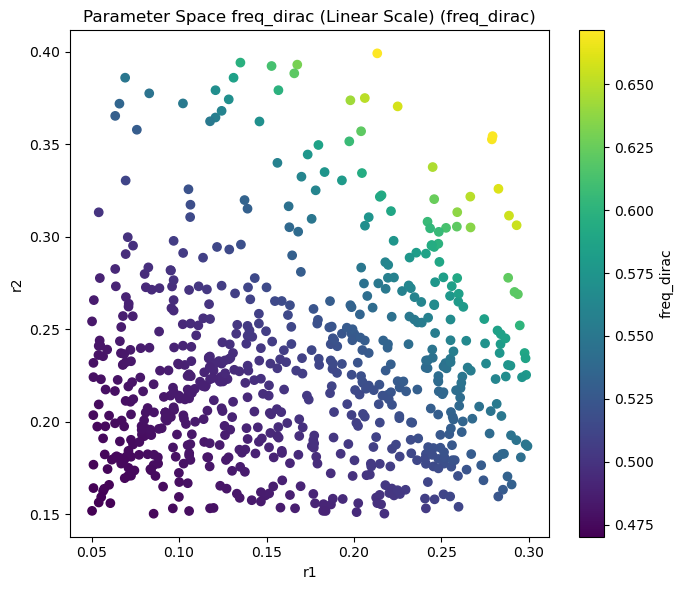

<Figure size 640x480 with 0 Axes>

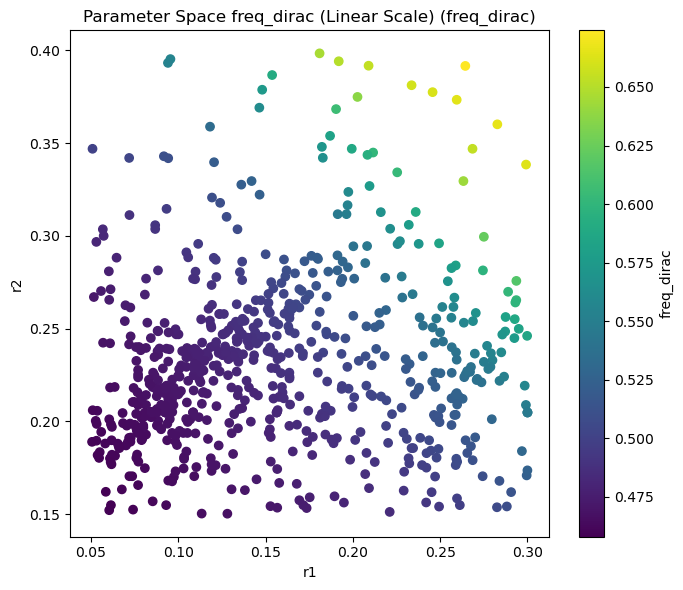

<Figure size 640x480 with 0 Axes>

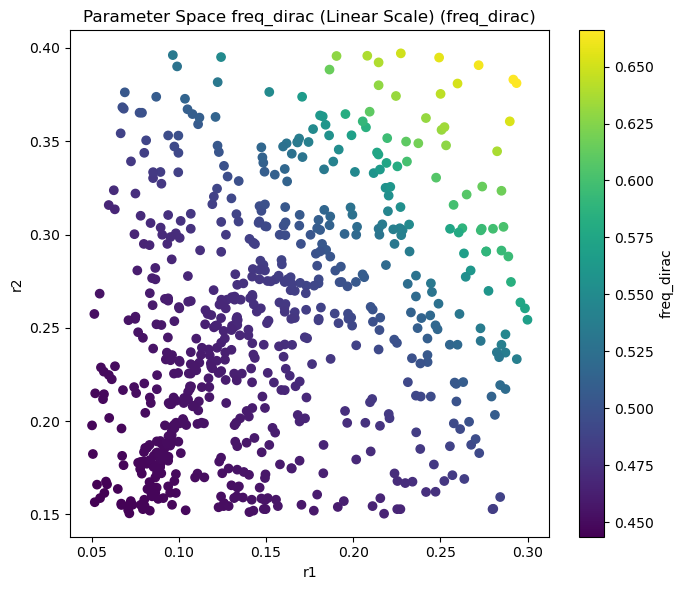

<Figure size 640x480 with 0 Axes>

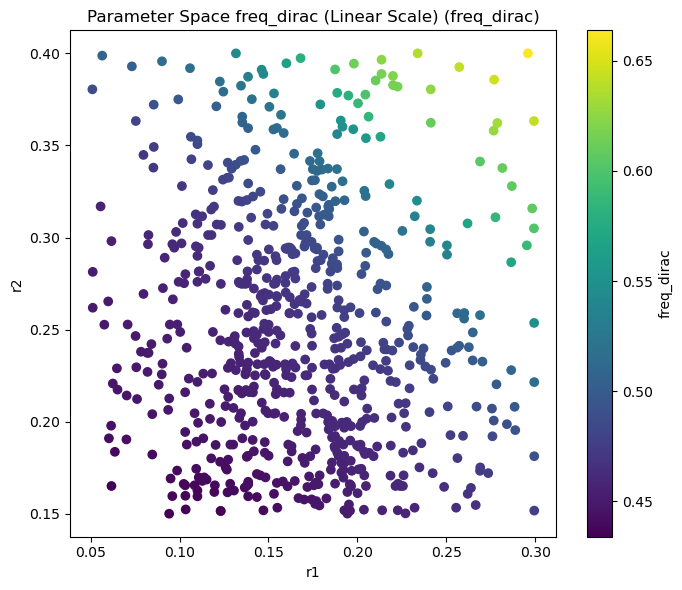

In [12]:
data_file_paths = []
data_file_names = []
for h in h_array:
    data_file_parent = f"{name}_h_{h:0.2f}"
    data_file_name = f"{name}_h_{h:0.2f}.de.data"
    data_file_path = f"{data_file_parent}/{data_file_name}"
    data_file_paths.append(data_file_path)
    data_file_names.append(data_file_name) 

for data_file_name, data_file_path in zip(data_file_names, data_file_paths):
    print(f"Plotting {data_file_name}")
    try:
        analyzer = OptimizationDataAnalyzer(data_file_path)
        plt.figure()
        analyzer.plot_optimization_points_freq_dirac(points_only=True)
        plt.savefig(f"{data_file_name}_freq_dirac.png")
        
    except Exception as e:
        pass
